<a href="https://colab.research.google.com/github/22104071/Quantitative_Market_Research_Project/blob/main/Quantitative_Research_Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

**Loading Data**

In [16]:
df = pd.read_csv('/content/Data.csv')
df['Date '] = pd.to_datetime(df['Date '])
df.set_index('Date ', inplace=True)
df.sort_values(by='Date ', inplace=True)

/tmp/ipykernel_3969/386583425.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date '] = pd.to_datetime(df['Date '])


In [17]:
print(df.head())

              Open      High       Low     Close   Shares Traded   \
Date                                                                
2024-04-01  22455.0  22529.95  22427.75  22462.00       243637071   
2024-04-02  22458.8  22497.60  22388.15  22453.30       289524237   
2024-04-03  22385.7  22521.10  22346.50  22434.65       309647491   
2024-04-04  22592.1  22619.00  22303.80  22514.65       400986156   
2024-04-05  22486.4  22537.60  22427.60  22513.70       242244731   

            Turnover (₹ Cr)  
Date                         
2024-04-01         21420.69  
2024-04-02         27940.93  
2024-04-03         30793.28  
2024-04-04         40705.56  
2024-04-05         24797.82  


In [18]:
print("The data Size is:",df.shape)

The data Size is: (249, 6)


In [19]:
print(df.info)

<bound method DataFrame.info of                Open      High       Low     Close   Shares Traded   \
Date                                                                 
2024-04-01  22455.00  22529.95  22427.75  22462.00       243637071   
2024-04-02  22458.80  22497.60  22388.15  22453.30       289524237   
2024-04-03  22385.70  22521.10  22346.50  22434.65       309647491   
2024-04-04  22592.10  22619.00  22303.80  22514.65       400986156   
2024-04-05  22486.40  22537.60  22427.60  22513.70       242244731   
...              ...       ...       ...       ...             ...   
2025-03-24  23515.40  23708.75  23433.50  23658.35       311900413   
2025-03-25  23751.50  23869.60  23601.40  23668.65       338216746   
2025-03-26  23700.95  23736.50  23451.70  23486.85       278590831   
2025-03-27  23433.95  23646.45  23412.20  23591.95       510302142   
2025-03-28  23600.40  23649.20  23450.20  23519.35       387455531   

            Turnover (₹ Cr)  
Date                       

**Data Quality Checks**



In [22]:
print('\nMissing_Values')
print(df.isnull().sum())


Missing_Values
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64


In [23]:
print('\nSummary Statistics')
print(df.describe())


Summary Statistics
              Open          High           Low         Close   Shares Traded   \
count    249.000000    249.000000    249.000000    249.000000    2.490000e+02   
mean   23791.889558  23898.429518  23655.939157  23776.711647    3.073877e+08   
std     1013.417492   1009.667801   1024.032435   1013.018384    1.006037e+08   
min    21861.500000  22105.050000  21281.450000  21884.500000    1.906457e+07   
25%    22930.750000  23007.450000  22798.350000  22932.450000    2.511898e+08   
50%    23769.100000  23869.600000  23601.400000  23727.650000    2.877036e+08   
75%    24543.800000  24638.800000  24378.100000  24541.150000    3.475916e+08   
max    26248.250000  26277.350000  26151.400000  26216.050000    1.006105e+09   

       Turnover (₹ Cr)  
count       249.000000  
mean      31519.651847  
std       11255.706424  
min        1572.770000  
25%       25462.050000  
50%       29113.880000  
75%       34639.780000  
max       93786.440000  


**Feature Engineering**

In [32]:
#Daily Returns
df['Daily_Return'] = df['Close '].pct_change()

In [35]:
#Log Returns
df['Log_Return'] = np.log(df['Close ']/df['Close '].shift(1))

In [77]:
#Moving Average
df['SMA_10'] = df['Close '].rolling(window=10).mean()
df['SMA_50'] = df['Close '].rolling(window=50).mean()

In [39]:
#Momentum Indicators
df['Momentum_50'] = df['Close '].diff(periods=50)
df['Momentum_20'] = df['Close '].diff(periods=20)

In [42]:
#Rolling Volatility
df['Volatility_50'] = df['Daily_Return'].rolling(window=50).std()*np.sqrt(252)
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()*np.sqrt(252)

**Visualization**

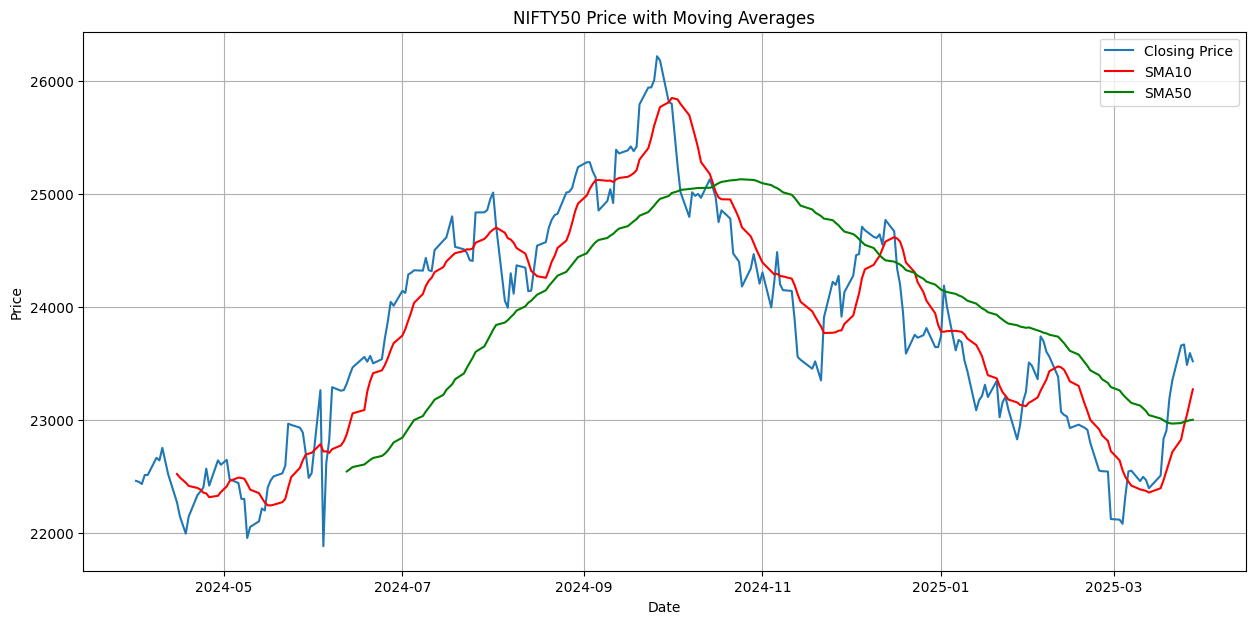

In [83]:
plt.figure(figsize=(15,7),)
plt.plot(df['Close '], label='Closing Price')
plt.plot(df['SMA_10'], label='SMA10', color = "r")
plt.plot(df['SMA_50'], label='SMA50', color = "g")
plt.title("NIFTY50 Price with Moving Averages")
plt.grid()
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

**Strategy 1 SMA CrossOver**

In [107]:
df["Signal_SMA"] = np.where((df["SMA_10"] > df["SMA_50"]) & (df["SMA_10"].shift(1) < df["SMA_50"].shift(1)), 1, 0)
df['Strategy_Return_SMA'] = (
    df['Signal_SMA'].shift(1)
    * df['Daily_Return']
)

**Strategy 2 Momentum**

In [108]:
df['Signal_Momentum'] = np.where(df['Momentum_50'] > 0, 1, 0)
df['Strategy_Return_Momentum'] = (
    df['Signal_Momentum'].shift(1)
    * df['Daily_Return']
)

**Equity Curves**

In [109]:
df['Market_Cumulative'] = (
    1 + df['Daily_Return']
).cumprod()

df['SMA_Cumulative'] = (
    1 + df['Strategy_Return_SMA']
).cumprod()

df['Momentum_Cumulative'] = (
    1 + df['Strategy_Return_Momentum']
).cumprod()

**Performance Function**

In [116]:
def performance_metrics(returns, cummulative_returns):
  returns = returns.dropna()
  sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()

  # Calculate Max Drawdown
  # The cummax() function returns a cumulative maximum.
  # We then calculate the drawdown from this rolling maximum.
  max_drawdown_values = (cummulative_returns - cummulative_returns.cummax()) / cummulative_returns.cummax()
  max_drawdown = max_drawdown_values.min()

  cagr = ((cummulative_returns.iloc[-1]) ** (252 / len(returns)) - 1)*100

  # Calculate Win Rate
  win_rate = (returns > 0).sum() / len(returns)

  return {
      "CAGR": cagr,
      "Sharpe": sharpe_ratio,
      "Max Drawdown": max_drawdown,
      "Win Rate": win_rate
  }

**Metrics**

In [117]:
market_metrics = performance_metrics(
    df['Daily_Return'],
    df['Market_Cumulative']
)

sma_metrics = performance_metrics(
    df['Strategy_Return_SMA'],
    df['SMA_Cumulative']
)

momentum_metrics = performance_metrics(
    df['Strategy_Return_Momentum'],
    df['Momentum_Cumulative']
)

**Comparison Table**

In [121]:
results = pd.DataFrame({
    "Metric": ["CAGR(%)", "Sharpe", "Max Drawdown", "Win Rate"],
    "Market": list(market_metrics.values()),
    "SMA": list(sma_metrics.values()),
    "Momentum": list(momentum_metrics.values())
})


In [122]:
print("\nPerformance Comparison")
print(results)


Performance Comparison
         Metric    Market       SMA  Momentum
0       CAGR(%)  4.784996  1.367894  3.345716
1        Sharpe  0.402765  1.354698  0.501439
2  Max Drawdown -0.157667  0.000000 -0.079353
3      Win Rate  0.504032  0.008065  0.221774


**Equity Curve Plot**

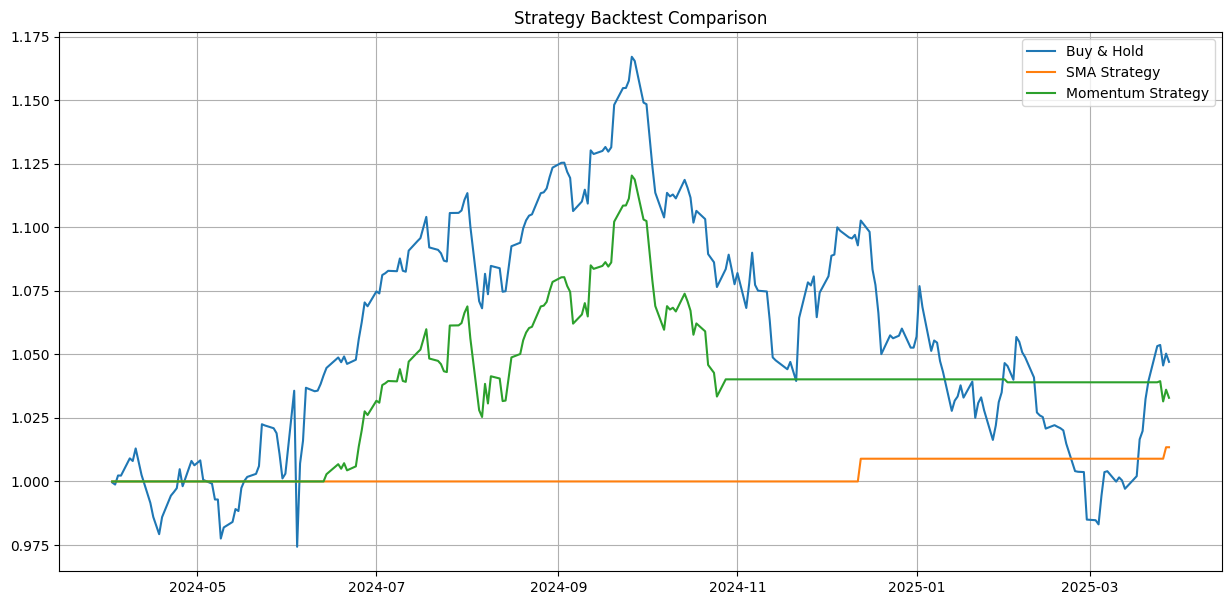

In [124]:
plt.figure(figsize=(15,7))

plt.plot(
    df['Market_Cumulative'],
    label='Buy & Hold'
)

plt.plot(
    df['SMA_Cumulative'],
    label='SMA Strategy'
)

plt.plot(
    df['Momentum_Cumulative'],
    label='Momentum Strategy'
)

plt.title("Strategy Backtest Comparison")
plt.legend()
plt.grid(True)

plt.show()